t :  ξ(t)
 0 :  жёлтый
 1 :  зелёный
 2 :  синий
 3 :  зелёный
 4 :  красный
 5 :  зелёный
 6 :  синий
 7 :  зелёный
 8 :  красный
 9 :  жёлтый
10 :  жёлтый
11 :  синий
12 :  зелёный
13 :  синий
14 :  оранжевый
15 :  жёлтый
16 :  синий
17 :  красный
18 :  зелёный
19 :  жёлтый
20 :  синий
21 :  оранжевый
22 :  синий
23 :  зелёный
24 :  синий
25 :  красный
26 :  жёлтый
27 :  красный
28 :  оранжевый
29 :  зелёный
30 :  синий


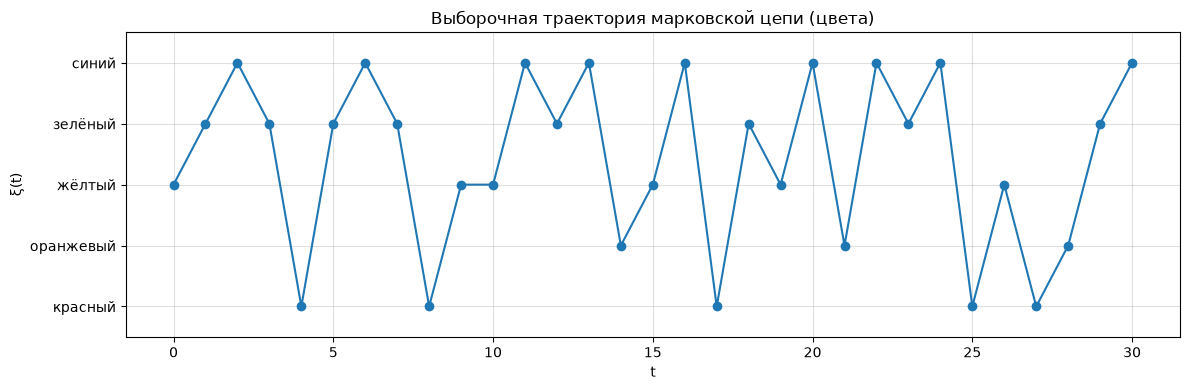

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Пространство состояний: именованные цвета
states = ["красный", "оранжевый", "жёлтый", "зелёный", "синий"]

# Начальное распределение pi
pi = np.array([0.0, 0.2, 0.6, 0.0, 0.2])

# Матрица переходных вероятностей P
P = np.array([
    [0.1, 0.2, 0.3, 0.4, 0.0],
    [0.0, 0.2, 0.2, 0.3, 0.3],
    [0.3, 0.0, 0.1, 0.1, 0.5],
    [0.4, 0.1, 0.2, 0.0, 0.3],
    [0.2, 0.3, 0.1, 0.4, 0.0],
])

# Моменты времени
T = np.arange(0, 31)  # t = 0, 1, ..., 30

# -----------------------------
# Генерация траектории
# -----------------------------
def generate_trajectory(pi, P, T, states, seed=None):
    """
    Генерирует одну выборочную траекторию марковской цепи.
    Возвращает список названий состояний для t из T.
    """
    rng = np.random.default_rng(seed)
    n_states = len(states)
    trajectory = []

    # Начальное состояние xi(0) ~ pi
    idx = rng.choice(n_states, p=pi)
    trajectory.append(states[idx])

    # Последующие состояния
    for _ in range(1, len(T)):
        idx = rng.choice(n_states, p=P[idx])
        trajectory.append(states[idx])

    return trajectory

# Генерируем траекторию
trajectory = generate_trajectory(pi, P, T, states, seed=42)

print("t :  ξ(t)")
for t, x in zip(T, trajectory):
    print(f"{t:2d} :  {x}")

# -----------------------------
# График траектории
# -----------------------------
# Для графика по оси Y удобно использовать числовые индексы состояний
state_to_y = {name: i for i, name in enumerate(states)}
y_values = [state_to_y[name] for name in trajectory]

plt.figure(figsize=(12, 4))
plt.plot(T, y_values, marker='o', linestyle='-', color='tab:blue')

# Подписи по оси Y — названия состояний
plt.yticks(range(len(states)), states)
plt.ylim(-0.5, len(states) - 0.5)

plt.xlabel("t")
plt.ylabel("ξ(t)")
plt.title("Выборочная траектория марковской цепи (цвета)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()